In [1]:
## import stuff
from datetime import date
from matplotlib import pyplot as plt
import numpy as np
import os
import tifffile as tiff
import glob as glob
from pathlib import Path

# we need to set the current path to the directory
# containing the suite3d repository, this hack should
# do the trick
os.chdir(os.path.dirname(os.path.abspath("")))

from suite3d.job import Job
from suite3d import io
from suite3d import plot_utils as plot

No MRCFile


In [2]:
# define path to data
#path = Path("/mnt/imaging1/imaging1/Veronique/2p_datasets/OFL/477116/20251118") # this is actually path to multiday data not 3d data
path = Path("/data/ofl_2p/20251118/split_tifs/")

# Check if it exists
if path.exists():
    print("Path exists!")
else:
    print("Path does not exist.")

# get tif files
tifs = io.get_tif_paths(path)
for tif in tifs: print(tif)




Path exists!
/data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_00000_09999.tif
/data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_09999_19998.tif
/data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_19998_29997.tif
/data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_29997_39996.tif
/data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_39996_40755.tif


In [3]:
print(io.get_vol_rate(tifs[0]))

29.96393939393939


In [4]:
# Set the mandatory parameters
# for now some parameters are just guesses
params = {
    # volume rate
    'fs': io.get_vol_rate(tifs[0]),

    # planes to analyze (we have 3 planes)
    'planes' : np.array([0,1,2]),
    # number of planes recorded
    'n_ch_tif' : 3,

    # Decay time of the Ca indicator in seconds. 1.3 for GCaMP6s. This example is for GCamP8m
    'tau' : 1.3,
    'lbm' : False,
    'num_colors' : 1, # how many color channels were recorded by scanimage
    'functional_color_channel' : 0, # which color channel is the functional one
     # voxel size in z,y,x in microns
    'voxel_size_um' : (30, 0.84, 0.84),
    # number of files to use for the initial pass
    # usually, ~500 frames is a good rule of thumb
    # we will just use 200 here for speed
    'n_init_files' :  1,  # more of those makes it crash due to mem issues
    "init_n_frames": 500,

    # 3D GPU registration - fast!
    '3d_reg' : True,
    'gpu_reg' : True,

    # note : 3D CPU is not supported yet
    'subtract_crosstalk' : False, # turn off some lbm-only features
    'fuse_strips' : False, # turn off some lbm-only features
    "cell_filt_xy_um": 8,


    "split_tif_size": 100,
    "peak_thresh": 0.5,
    "extend_thresh": 0.005,
    #"activity_thresh": 8.0,
    #"percentile": 90.0,
    #"extend_thresh": 0.1,
    #"max_pix": 1000,




}



In [17]:
import json


def jsonable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    return obj

params_json_path = Path("/docs/params_default_suite3d.json")

with params_json_path.open("w") as f:
    json.dump(params, f, indent=2, default=jsonable)

print(f"Saved params to {params_json_path.resolve()}")

Saved params to /home/battaglia/src/ofl_2p_analysis/docs/params.json


In [5]:
### Create the job
job = Job(r'/data/ofl_2p/20251118','xy_1000', tifs = tifs,
          params=params, create=True, overwrite=True, verbosity = 3)
job.params.update(params)


Job directory /data/ofl_2p/20251118/s3d-xy_1000 already exists
Loading job directory for xy_1000 in /data/ofl_2p/20251118
   Loading dirs 
      Found dir registered_fused_data
      Found dir summary
      Found dir iters
   Loading default params
      Updating param fs
      Updating param planes
      Updating param n_ch_tif
      Updating param tau
      Updating param lbm
      Updating param num_colors
      Updating param functional_color_channel
      Updating param voxel_size_um
      Updating param n_init_files
      Updating param init_n_frames
      Updating param 3d_reg
      Updating param gpu_reg
      Updating param subtract_crosstalk
      Updating param fuse_strips
      Updating param cell_filt_xy_um
      Updating param split_tif_size
      Updating param peak_thresh
      Updating param extend_thresh
   Updated main params file


In [6]:
job.run_init_pass()

   Saved a copy of params at /data/ofl_2p/20251118/s3d-xy_1000/summary
   Updated main params file
Launching initial pass
Saving summary to /data/ofl_2p/20251118/s3d-xy_1000/summary/summary.npy
   Loading init tifs with 3 channels
      Loading tiff 1/1: /data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_19998_29997.tif
   Loaded 1 files, total 9.76 GB
   Selecting 500 random frames from the init tif files
   Loaded movie with 500 frames and shape 3, 512, 512
      Enforcing positivity in mean image
   No crosstalk estimation or subtraction
   Using 3d registration
   Computing plane alignment shifts
   Applying plane alignment shifts
   Launching 3D GPU reference image calculation
      Seeding reference image with most active frames
      Completed iter 1 out of 8 in  2.21s using  69/500 frames
      Completed iter 2 out of 8 in  2.14s using  123/500 frames
      Completed iter 3 out of 8 in  2.15s using  177/500 frames
      Completed iter 4 out of 8 in  2.29s using  231/

In [7]:
# If you have large tiffs, split the large tiffs into files of size 100 after registration
job.params['split_tif_size'] = 100

(<Figure size 450x600 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x764200ec4b10>)

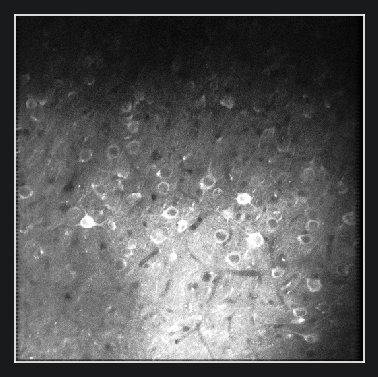

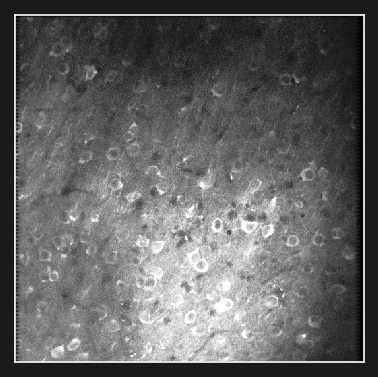

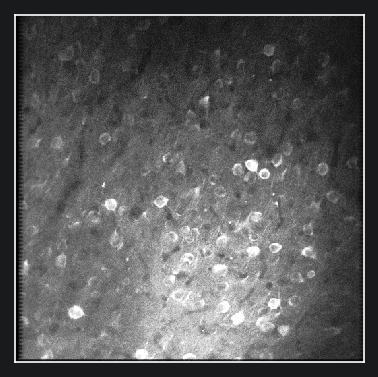

In [8]:
# OPTIONAL: load and take a look at the reference image
summary = job.load_summary()
ref_img = summary['ref_img_3d']

# # view 1 plane at a time
plot.show_img(ref_img[0], figsize=(3,4))
plot.show_img(ref_img[1], figsize=(3,4))
plot.show_img(ref_img[2], figsize=(3,4))

# # interactive 3D viewer
# plot.VolumeViewer(ref_img)

In [9]:
job.register()

      Found dir /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data
      Updating self.dirs tag registered_fused_data
   Saved a copy of params at /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data
   Updated main params file
   Starting registration: 3D: True, GPU: True
   Not clipping frames for registration
Will analyze 5 tifs in 5 batches
   Enforcing positivity
   Launching IO thread
         Memory at batch 0.  Total Used: 011.772 GB, Virtual Available: 053.783 GB, Virtual Used: 008.701 GB, Swap Used: 003.071 GB
Loading Batch 0 of 4
      Loading tiff 1/1: /data/ofl_2p/20251118/split_tifs/477116_20251118_00001_frames_00000_09999.tif
   Loaded 1 files, total 9.76 GB
   Batch 0 IO thread joined
         Memory after IO thread joinTotal Used: 020.826 GB, Virtual Available: 044.747 GB, Virtual Used: 017.736 GB, Swap Used: 003.090 GB
         Memory after movie copied from threadTotal Used: 030.617 GB, Virtual Available: 034.957 GB, Virtual Used: 027.526 GB, Swap Used: 003.0

/home/battaglia/src/suite3d/suite3d/quality_metrics.py:41: RuntimeWarning: invalid value encountered in divide
  dff = df / fs.mean(axis=1,keepdims=True)
/home/battaglia/src/suite3d/suite3d/quality_metrics.py:43: RuntimeWarning: All-NaN slice encountered
  noise_level = n.nanmedian(abs_d_dff, axis=1)


         Saved in 0.27 sec
      Computing quality metrics and saving
      Saving fused, registered file of shape (3, 100, 516, 518) to /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data/fused_reg_data0004.npy
         Saved in 0.28 sec
      Computing quality metrics and saving
      Saving fused, registered file of shape (3, 100, 516, 518) to /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data/fused_reg_data0005.npy
         Saved in 0.31 sec
      Computing quality metrics and saving
      Saving fused, registered file of shape (3, 100, 516, 518) to /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data/fused_reg_data0006.npy
         Saved in 0.27 sec
      Computing quality metrics and saving
      Saving fused, registered file of shape (3, 100, 516, 518) to /data/ofl_2p/20251118/s3d-xy_1000/registered_fused_data/fused_reg_data0007.npy
         Saved in 0.27 sec
      Computing quality metrics and saving
      Saving fused, registered file of shape (3, 100, 516, 518) to

In [10]:
corr_map = job.calculate_corr_map()

      Found dir /data/ofl_2p/20251118/s3d-xy_1000/corrmap
      Updating self.dirs tag corrmap
      Found dir /data/ofl_2p/20251118/s3d-xy_1000/mov_sub
      Updating self.dirs tag mov_sub
   Updated detection_timebin to 23 based on framerate and tau
   Saved a copy of params at /data/ofl_2p/20251118/s3d-xy_1000/corrmap
   Updated main params file
   Computing correlation map of movie with 13585 frames, volume shape: 3, 516, 518
      Running batch 1 of 17
      Binning with timebin of size 23
         Timer batch_timebin completed in 0.002 sec
         Timer prep completed in 0.712 sec
         Timer batch_setup completed in 0.022 sec
         Timer batch_edgecrop completed in 0.002 sec
         Timer accum_meanmeax completed in 0.029 sec
         Timer batch_rolling_mean_filt completed in 0.022 sec
         Timer batch_accum_sdmov completed in 0.052 sec
         Timer batch_norm_sdmov completed in 0.012 sec
         Loading movie of size (34, 3, 516, 518) into shared memory
        

/home/battaglia/miniforge3/envs/ofl-2p-analysis/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 2 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/home/battaglia/miniforge3/envs/ofl-2p-analysis/lib/python3.11/multiprocessing/resource_tracker.py:267: UserWarning: resource_tracker: '/psm_f6ec9a28': [Errno 2] No such file or directory: '/psm_f6ec9a28'
  warnings.warn('resource_tracker: %r: %s' % (name, e))
/home/battaglia/miniforge3/envs/ofl-2p-analysis/lib/python3.11/multiprocessing/resource_tracker.py:267: UserWarning: resource_tracker: '/psm_21e521f5': [Errno 2] No such file or directory: '/psm_21e521f5'
  warnings.warn('resource_tracker: %r: %s' % (name, e))
/home/battaglia/miniforge3/envs/ofl-2p-analysis/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 2 leaked shared_memory objects to clean up at shutdown
 

         Timer batch_setup completed in 0.024 sec
         Timer batch_edgecrop completed in 0.002 sec
         Timer accum_meanmeax completed in 0.044 sec
         Timer batch_rolling_mean_filt completed in 0.022 sec
         Timer batch_accum_sdmov completed in 0.052 sec
         Timer batch_norm_sdmov completed in 0.012 sec
         Loading movie of size (34, 3, 516, 518) into shared memory
         Timer dtu_shmem completed in 0.093 sec
         Subtracting neuropil and applying cell filters
         Timer dtu_npsub_conv3d completed in 1.483 sec
         Reducing filtered movie to compute correlation map
         Timer dtu_vmap completed in 0.050 sec
         Timer dtu_cleanup completed in 0.064 sec
         Timer batch_filt_reduce completed in 1.693 sec
         Timer batch_accum_vmap completed in 0.003 sec
         Timer batch completed in 2.478 sec
         Timer save completed in 0.140 sec
      Running batch 3 of 17
      Binning with timebin of size 23
         Timer batch_ti

In [11]:
res = job.load_corr_map_results()
vmap = res['vmap']

(<Figure size 450x600 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7642014af0d0>)

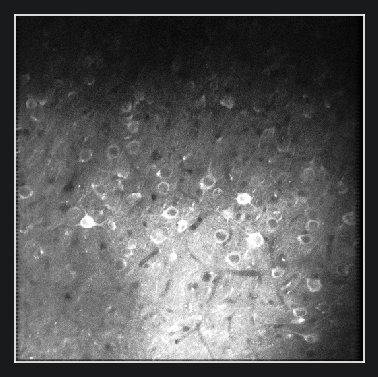

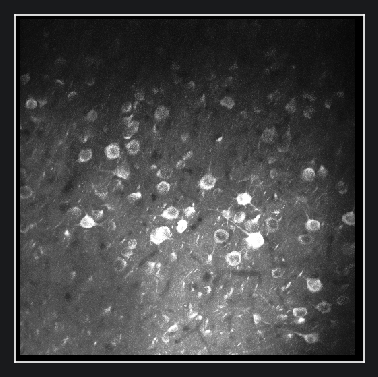

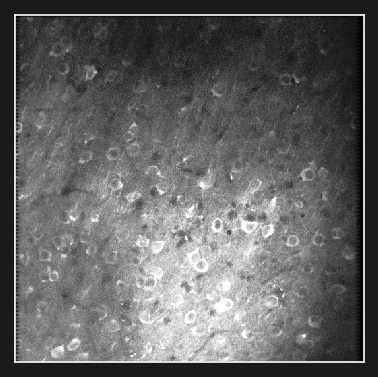

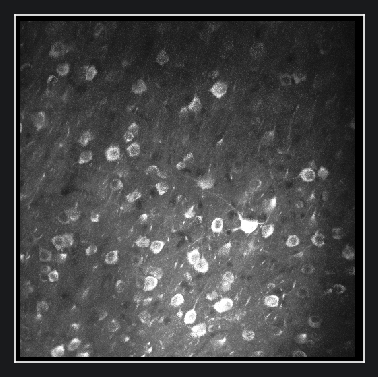

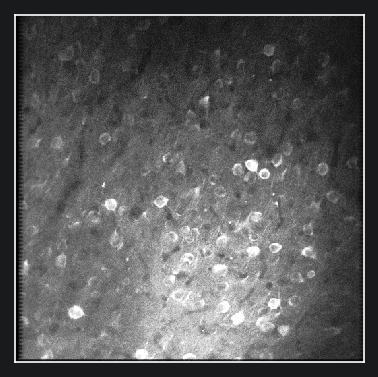

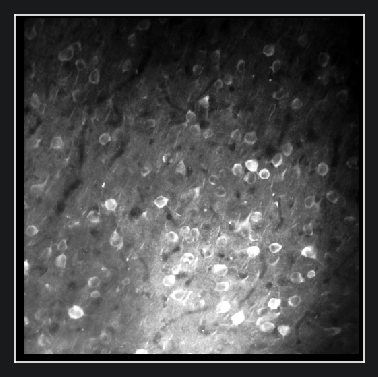

In [12]:
plot.show_img(ref_img[0], figsize=(3,4))
plot.show_img(res['max_img'][0], figsize=(3,4))

plot.show_img(ref_img[1], figsize=(3,4))
plot.show_img(res['max_img'][1], figsize=(3,4))

plot.show_img(ref_img[2], figsize=(3,4))
plot.show_img(res['mean_img'][2], figsize=(3,4))

In [13]:
job.params['patch_size_xy'] = (1000, 1000)
# for speed, only segment a single patch
job.segment_rois()



      Found dir /data/ofl_2p/20251118/s3d-xy_1000/segmentation
      Updating self.dirs tag segmentation
   Saved a copy of params at /data/ofl_2p/20251118/s3d-xy_1000/segmentation
   Updated main params file
      Found dir /data/ofl_2p/20251118/s3d-xy_1000/rois
      Updating self.dirs tag rois
   Saving results to /data/ofl_2p/20251118/s3d-xy_1000/segmentation and /data/ofl_2p/20251118/s3d-xy_1000/rois 
dict_keys(['max_img', 'mean_img', 'vmap', 'vmap_raw', 'all_params'])
   Detecting from patch 1 / 1
      Found dir /data/ofl_2p/20251118/s3d-xy_1000/segmentation/patch-0000
         Loading 0.86 GB movie to memory, shape: (578, 3, 516, 518) 
         Loaded
         Loading movie patch to shared memory
         Loaded
      Starting extraction with peak_thresh: 0.500 and Th2: 5.000
         Iter 0000: running 16 ROIs in parallel
         Added cell 1 at 00, 334, 356, peak: 6.611, thresh: 5.000, 142 frames, 754 pixels
         Added cell 2 at 01, 314, 346, peak: 5.161, thresh: 5.000, 

'/data/ofl_2p/20251118/s3d-xy_1000/rois'

In [14]:
job.compute_npil_masks()
traces = job.extract_and_deconvolve()

   Updated main params file
   Movie shape: (3, 13585, 516, 518)
693
   Extracting 693 valid cells, and saving cell flags to /data/ofl_2p/20251118/s3d-xy_1000/rois/iscell_extracted.npy
   Extracting activity
         Will extract in 28 batches of 500
   Saving intermediate results to /data/ofl_2p/20251118/s3d-xy_1000/rois
   Deconvolving
   Saving to /data/ofl_2p/20251118/s3d-xy_1000/rois


In [15]:
job.export_results('/data/ofl_2p/20251118/results',result_dir_name='rois')

   Created dir /data/ofl_2p/20251118/results/s3d-results-xy_1000 to export results
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/stats_small.npy
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/info.npy
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/F.npy
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/spks.npy
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/Fneu.npy
      Loading from /data/ofl_2p/20251118/s3d-xy_1000/rois/iscell.npy
      Overwriting existing /data/ofl_2p/20251118/results/s3d-results-xy_1000/s3d-params.npy
      Overwriting existing /data/ofl_2p/20251118/results/s3d-results-xy_1000/frames.npy
      Overwriting existing /data/ofl_2p/20251118/results/s3d-results-xy_1000/stats.npy
      Saved stats.npy to /data/ofl_2p/20251118/results/s3d-results-xy_1000
      Overwriting existing /data/ofl_2p/20251118/results/s3d-results-xy_1000/info.npy
      Saved info.npy to /data/ofl_2p/20251118/results/s3d-results-xy_1000
      O

In [16]:
print(np.__version__)

2.4.3


In [ ]:
%%sql
